In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xyzservices

## read in, basic stats

In [2]:
daily = gpd.read_parquet('./test_stops_2026-08-12.parquet').rename(columns={'agency': 'analysis_name'})

In [3]:
monthly = gpd.read_parquet('./test_stops_monthly_2026-08-01.parquet')

In [4]:
daily.describe()

,n_routes,n_arrivals,n_hours_in_service,meters_to_ca_state_highway
count,79024.000000,79024.000000,79024.000000,7.902400e+04
mean,1.390299,39.703989,14.233182,4.430925e+04
std,1.001037,45.741351,6.473395,3.471584e+05
min,1.000000,0.000000,0.000000,0.000000e+00
25%,1.000000,13.000000,12.000000,3.447750e+02
50%,1.000000,27.000000,16.000000,8.463000e+02
75%,1.000000,52.000000,18.000000,1.706525e+03
max,31.000000,820.000000,24.000000,4.024699e+06


In [5]:
monthly.describe()

,daily_n_hours_in_service,n_arrivals,n_routes,meters_to_ca_state_highway
count,84539.000000,84539.000000,84539.000000,8.453900e+04
mean,14.631649,37.909474,1.363122,5.771561e+04
std,6.187381,41.234991,0.926457,3.983188e+05
min,0.000000,1.000000,1.000000,0.000000e+00
25%,13.000000,14.000000,1.000000,3.536000e+02
50%,16.000000,26.000000,1.000000,8.479000e+02
75%,19.000000,48.000000,1.000000,1.693900e+03
max,24.000000,820.000000,31.000000,4.024699e+06


In [6]:
daily.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 79024 entries, 0 to 79023
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   analysis_name               76440 non-null  object  
 1   stop_id                     79024 non-null  object  
 2   stop_name                   79024 non-null  object  
 3   n_routes                    79024 non-null  int64   
 4   route_ids_served            79024 non-null  object  
 5   route_types_served          79024 non-null  object  
 6   n_arrivals                  79024 non-null  int64   
 7   n_hours_in_service          79024 non-null  int64   
 8   meters_to_ca_state_highway  79024 non-null  float64 
 9   base64_url                  79024 non-null  object  
 10  district_name               79024 non-null  object  
 11  geometry                    79024 non-null  geometry
dtypes: float64(1), geometry(1), int64(3), object(7)
memory usage: 7.2+

In [7]:
daily=daily.dropna(subset=['analysis_name'])

In [8]:
daily[daily.stop_id == '13560']

,analysis_name,stop_id,stop_name,n_routes,route_ids_served,route_types_served,n_arrivals,n_hours_in_service,meters_to_ca_state_highway,base64_url,district_name,geometry
43695,Los Angeles County Metropolitan Transportation...,13560,Grand / 3rd,10,"14-13201, 487-13201, 53-13201, 55-13201, 60-13...",3,819,24,537.3,aHR0cHM6Ly9naXRsYWIuY29tL0xBQ01UQS9ndGZzX2J1cy...,07 - Los Angeles / Ventura,POINT (-118.25157 34.05288)
69289,City and County of San Francisco,13560,33rd Ave & Geary Blvd,1,38,3,48,15,1493.0,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L2RhdGFmZW...,04 - Bay Area / Oakland,POINT (-122.49338 37.77957)


In [9]:
monthly.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 84539 entries, 0 to 84538
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   name                        84539 non-null  object  
 1   stop_id                     84539 non-null  object  
 2   stop_name                   84539 non-null  object  
 3   geometry                    84539 non-null  geometry
 4   routetypes                  84539 non-null  object  
 5   route_ids_served            84539 non-null  object  
 6   daily_n_hours_in_service    84539 non-null  float64 
 7   n_arrivals                  84539 non-null  int32   
 8   n_routes                    84539 non-null  int64   
 9   meters_to_ca_state_highway  84539 non-null  float64 
 10  analysis_name               84539 non-null  object  
 11  district_name               84539 non-null  object  
dtypes: float64(2), geometry(1), int32(1), int64(1), object(7)
memory u

<Axes: >

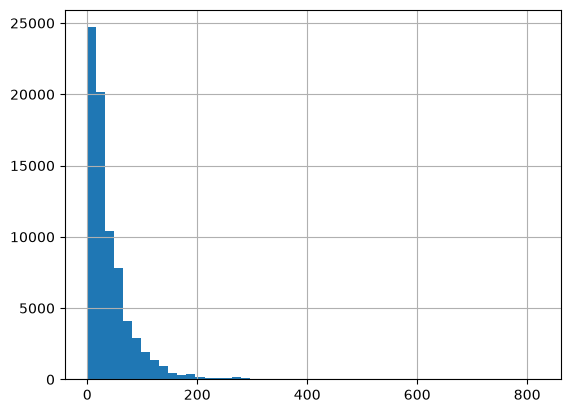

In [10]:
daily.n_arrivals.hist(bins=50)

<Axes: >

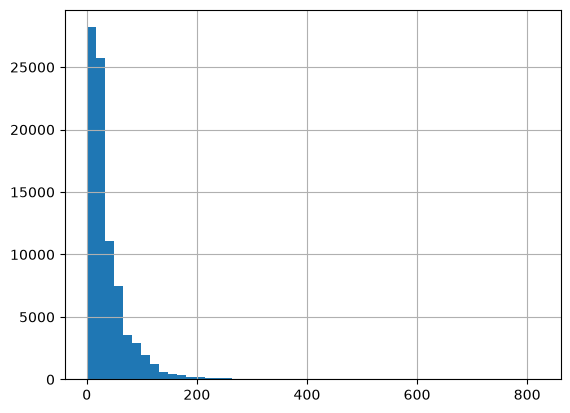

In [11]:
monthly_sub_1000 = monthly[monthly.n_arrivals <= 1000] # for display
monthly_sub_1000.n_arrivals.hist(bins=50)

## Join daily to monthly

In [12]:
monthly_to_join = monthly.copy()[['analysis_name', 'stop_id', 'n_arrivals']]

In [13]:
compare = pd.merge(daily, monthly_to_join, on=['analysis_name', 'stop_id'], suffixes=('', '_monthly'))
compare = compare[compare.n_arrivals > 0]
compare['monthly_daily_ratio'] = compare.n_arrivals_monthly / compare.n_arrivals
compare['monthly_daily_ratio_log'] = np.log(compare.monthly_daily_ratio)
compare = compare.round(3)

In [14]:
compare.sort_values(by='monthly_daily_ratio')

,analysis_name,stop_id,stop_name,n_routes,route_ids_served,route_types_served,n_arrivals,n_hours_in_service,meters_to_ca_state_highway,base64_url,district_name,geometry,n_arrivals_monthly,monthly_daily_ratio,monthly_daily_ratio_log
43118,San Luis Obispo Regional Transit Authority,159,Downtown Transit Center,8,"1A, 1B, 2A, 2B, 3A, 3B, 4A, 4B",3,228,15,356.9,aHR0cHM6Ly9zbG9jaXR5LmNvbm5leGlvbnoubmV0L3J0dC...,05 - San Luis Obispo / Santa Barbara,POINT (-120.66228 35.28273),12,0.053,-2.944
54796,Solano Transportation Authority,826007,East 5th St & East N St,1,70,3,16,16,97.7,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L2RhdGFmZW...,04 - Bay Area / Oakland,POINT (-122.14598 38.05200),1,0.062,-2.773
53526,City of Santa Rosa,80397,Coffey Ln at Dogwood Dr,1,10,3,15,15,1050.8,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L2RhdGFmZW...,04 - Bay Area / Oakland,POINT (-122.74704 38.47676),1,0.067,-2.708
74250,Alameda-Contra Costa Transit District,52866,E 14th St & Sybil Av,2,"801, 9",3,79,24,9.5,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L2RhdGFmZW...,04 - Bay Area / Oakland,POINT (-122.14988 37.72067),6,0.076,-2.578
25489,San Benito County Local Transportation Authority,17660,Veteran's Park,1,610,3,33,18,576.8,aHR0cHM6Ly9kYXRhLnRyaWxsaXVtdHJhbnNpdC5jb20vZ3...,05 - San Luis Obispo / Santa Barbara,POINT (-121.38374 36.84702),4,0.121,-2.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77860,San Diego International Airport,TL-3,Terminal 1 - Terminal 2,3,"TL-1, TL-2, TL-5",3,3,1,489.6,aHR0cHM6Ly9hY2VzaHV0dGxlcy50cmFuc2xvYy5jb20vU2...,11 - San Diego,POINT (-117.18447 32.73828),142,47.333,3.857
75889,City of San Clemente,194263,Outlets at San Clemente,2,"7668, 7671",3,2,1,238.2,aHR0cHM6Ly9wYXNzaW8zLmNvbS9zY3Ryb2xsZXkvcGFzc2...,12 - Santa Ana,POINT (-117.62799 33.43939),100,50.000,3.912
73459,City of San Clemente,194270,Granada,2,"7668, 7672",3,1,1,917.8,aHR0cHM6Ly9wYXNzaW8zLmNvbS9zY3Ryb2xsZXkvcGFzc2...,12 - Santa Ana,POINT (-117.61900 33.42259),70,70.000,4.248
78876,San Diego International Airport,TL-13,Terminal 1 Curbside Pickup,2,"TL-4, TL-5",3,2,1,1686.0,aHR0cHM6Ly9hY2VzaHV0dGxlcy50cmFuc2xvYy5jb20vU2...,11 - San Diego,POINT (-117.19775 32.73214),257,128.500,4.856


In [15]:
compare.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 75808 entries, 0 to 79183
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   analysis_name               75808 non-null  object  
 1   stop_id                     75808 non-null  object  
 2   stop_name                   75808 non-null  object  
 3   n_routes                    75808 non-null  int64   
 4   route_ids_served            75808 non-null  object  
 5   route_types_served          75808 non-null  object  
 6   n_arrivals                  75808 non-null  int64   
 7   n_hours_in_service          75808 non-null  int64   
 8   meters_to_ca_state_highway  75808 non-null  float64 
 9   base64_url                  75808 non-null  object  
 10  district_name               75808 non-null  object  
 11  geometry                    75808 non-null  geometry
 12  n_arrivals_monthly          75808 non-null  int32   
 13  monthly_daily

In [16]:
compare.describe()

,n_routes,n_arrivals,n_hours_in_service,meters_to_ca_state_highway,n_arrivals_monthly,monthly_daily_ratio,monthly_daily_ratio_log
count,75808.000000,75808.000000,75808.000000,7.580800e+04,75808.000000,75808.000000,75808.000000
mean,1.400551,43.154865,15.257730,6.225174e+04,39.072578,0.946407,-0.087821
std,1.034349,46.238286,5.569372,4.138465e+05,42.518558,0.995683,0.177975
min,1.000000,1.000000,1.000000,0.000000e+00,1.000000,0.053000,-2.944000
25%,1.000000,15.000000,13.000000,3.536000e+02,14.000000,0.866000,-0.144000
50%,1.000000,30.000000,16.000000,8.477000e+02,26.000000,0.923000,-0.080000
75%,1.000000,58.000000,19.000000,1.684000e+03,50.000000,1.000000,0.000000
max,31.000000,820.000000,24.000000,4.024699e+06,820.000000,128.500000,4.856000


In [17]:
import numpy as np

<Axes: >

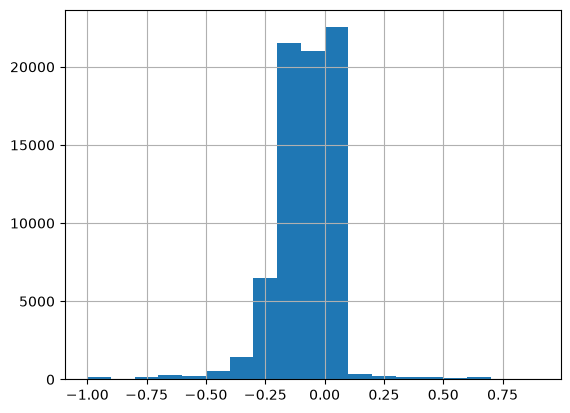

In [18]:
compare.monthly_daily_ratio_log.hist(bins = np.arange(-1, 1, .1))

## Mapping

In [19]:
import branca
cmap = branca.colormap.linear.PuOr_05
cmap = cmap.scale(-2, 2)
cmap.text_color = 'white'
cmap

colormap should center on zero (daily monthly equal), then fan out

In [20]:
to_map = compare[['n_arrivals', 'n_arrivals_monthly', 'monthly_daily_ratio',
                           'monthly_daily_ratio_log', 'analysis_name', 'route_ids_served',
                           'stop_id', 'stop_name', 'geometry']]

In [21]:
to_map.analysis_name.value_counts()[:10]

analysis_name
Los Angeles County Metropolitan Transportation Authority    12000
Santa Clara Valley Transportation Authority                  6294
Orange County Transportation Authority                       5066
Alameda-Contra Costa Transit District                        4225
City and County of San Francisco                             3246
City of Los Angeles                                          2780
Sacramento Regional Transit District                         2532
OmniTrans                                                    2274
Riverside Transit Agency                                     2145
Foothill Transit                                             1983
Name: count, dtype: int64

In [22]:
to_map.analysis_name.value_counts()[:10].index

Index(['Los Angeles County Metropolitan Transportation Authority',
       'Santa Clara Valley Transportation Authority',
       'Orange County Transportation Authority',
       'Alameda-Contra Costa Transit District',
       'City and County of San Francisco', 'City of Los Angeles',
       'Sacramento Regional Transit District', 'OmniTrans',
       'Riverside Transit Agency', 'Foothill Transit'],
      dtype='object', name='analysis_name')

In [23]:
top_10_agencies = to_map.analysis_name.value_counts()[:10].index

In [24]:
in_top_10 = to_map[to_map.analysis_name.isin(top_10_agencies)]

In [25]:
out_top_10 = to_map[~to_map.analysis_name.isin(top_10_agencies)]

In [30]:
# in_top_10.query('analysis_name == "Sacramento Regional Transit District"').explore(column='monthly_daily_ratio_log', cmap=cmap, tiles=xyzservices.providers.CartoDB.DarkMatter)

22

In [29]:
to_map.sort_values('monthly_daily_ratio', ascending=False)

,n_arrivals,n_arrivals_monthly,monthly_daily_ratio,monthly_daily_ratio_log,analysis_name,route_ids_served,stop_id,stop_name,geometry
78876,2,257,128.500,4.856,San Diego International Airport,"TL-4, TL-5",TL-13,Terminal 1 Curbside Pickup,POINT (-117.19775 32.73214)
78877,2,257,128.500,4.856,San Diego International Airport,"TL-4, TL-5",TL-14,Terminal 2 Curbside Pickup,POINT (-117.20306 32.73153)
73459,1,70,70.000,4.248,City of San Clemente,"7668, 7672",194270,Granada,POINT (-117.61900 33.42259)
75889,2,100,50.000,3.912,City of San Clemente,"7668, 7671",194263,Outlets at San Clemente,POINT (-117.62799 33.43939)
77860,3,142,47.333,3.857,San Diego International Airport,"TL-1, TL-2, TL-5",TL-3,Terminal 1 - Terminal 2,POINT (-117.18447 32.73828)
...,...,...,...,...,...,...,...,...,...
25489,33,4,0.121,-2.110,San Benito County Local Transportation Authority,610,17660,Veteran's Park,POINT (-121.38374 36.84702)
74250,79,6,0.076,-2.578,Alameda-Contra Costa Transit District,"801, 9",52866,E 14th St & Sybil Av,POINT (-122.14988 37.72067)
53526,15,1,0.067,-2.708,City of Santa Rosa,10,80397,Coffey Ln at Dogwood Dr,POINT (-122.74704 38.47676)
54796,16,1,0.062,-2.773,Solano Transportation Authority,70,826007,East 5th St & East N St,POINT (-122.14598 38.05200)


### August 2026 Review

* SacRT --> tables agree, look to scripts
    * Florin LRT, 5203, 87daily, 153 monthly
    * Meadowview LRT, 5200, 68, 121
* AC Transit 57718 --> tables agree, look to scripts

In [32]:
# out_top_10.head(15000).explore(column='monthly_daily_ratio_log', cmap=cmap)